      MaritalStatus  Age  Income Level
0           Married   23         70541
1           Widowed   26         54168
2            Single   29         73899
3          Divorced   20         63381
4         Separated   25         38794
...             ...  ...           ...
53498      Divorced   35        120850
53499        Single   61        122309
53500      Divorced   25         49258
53501       Married   42         66301
53502      Divorced   20        136632

[53503 rows x 3 columns]
['Married' 'Widowed' 'Single' 'Divorced' 'Separated']


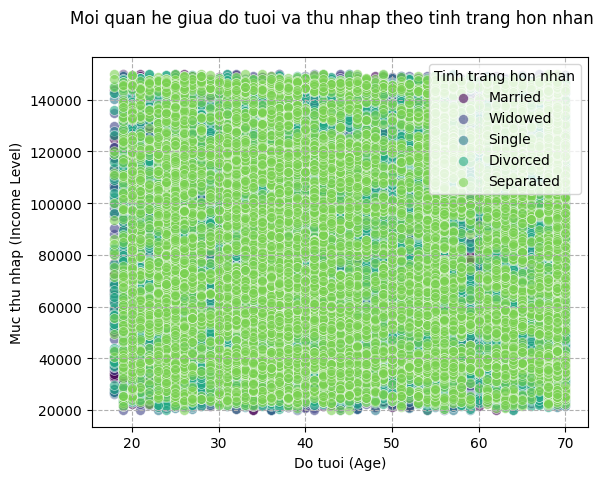

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px


df_contact_time=pd.read_csv('ContactTime.csv')
df_customer_data=pd.read_csv('CustomerData.csv')
df_education_level=pd.read_csv('EducationLevel.csv')
df_geographic=pd.read_csv('Geographic.csv')
df_interaction_channel=pd.read_csv('InteractionChannel.csv')
df_language=pd.read_csv('Language.csv')
df_marital_status=pd.read_csv('MaritalStatus.csv')
df_occupation=pd.read_csv('Occupation.csv')
df_policy_type=pd.read_csv('PolicyType.csv')
#Cau 1
df01=df_customer_data.merge(df_marital_status,on='MaritalID',how='inner')
df01=df01[['MaritalStatus','Age','Income Level']]
print(df01)

marital_status=df01['MaritalStatus'].unique()
print(marital_status)
cmap_object=plt.colormaps.get_cmap('viridis')
color_map={status:cmap_object(i/len(marital_status)) for i, status in enumerate(marital_status)}
for status in marital_status:
    df_subset=df01[df01['MaritalStatus']==status]
    plt.scatter(x=df_subset['Age'],y=df_subset['Income Level'],
                label=status,color=color_map[status],
                alpha=0.6,edgecolors='w',linewidths=0.5,s=50)
    plt.suptitle('Moi quan he giua do tuoi va thu nhap theo tinh trang hon nhan')
    plt.xlabel('Do tuoi (Age)')
    plt.ylabel('Muc thu nhap (Income Level)')
    plt.grid(linestyle='--')
    plt.legend(title='Tinh trang hon nhan',loc='upper right')
    




Occupation
Nurse           4521
Doctor          5573
Artist          5666
Engineer        5704
Lawyer          5775
Manager         5803
Teacher         5906
Entrepreneur    6636
Salesperson     7919
Name: OccupationID, dtype: int64


Text(, 0, '')

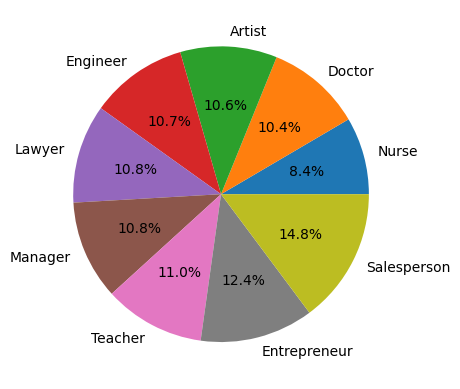

In [ ]:
#cau 2
df_mer=df_customer_data.merge(df_occupation,on='OccupationID',how='inner')
df_02=df_mer.groupby('Occupation')['OccupationID'].size().sort_values()
print(df_02)
plt.pie(x=df_02,autopct='%1.1f%%',labels=df_02.index)
plt.ylabel('')
plt.Text('')

Text(0.5, 1.0, 'Phan phoi phi bao hiem theo loai chinh sach va gioi tinh')

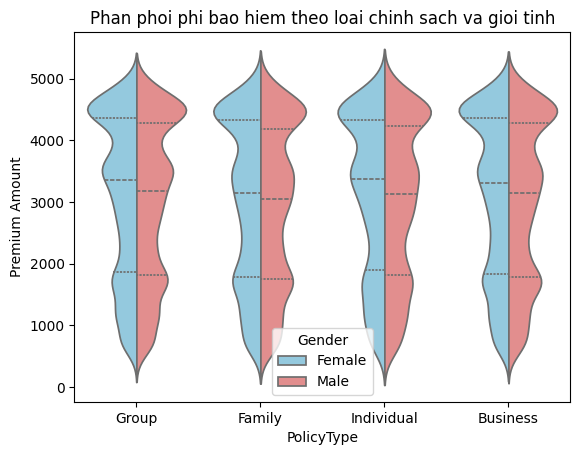

In [3]:
#Cau 3
df_mer03=df_customer_data.merge(df_policy_type,on='PolicyTypeID',how='inner')
sns.violinplot(data=df_mer03,x='PolicyType',y='Premium Amount',hue='Gender',split=True,inner='quartile',palette=['skyblue','lightcoral'])
plt.title('Phan phoi phi bao hiem theo loai chinh sach va gioi tinh')


C:\Users\Anh Thu\AppData\Local\Temp\ipykernel_25608\23170346.py:10: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot=df_mer.pivot_table(index='EducationLevel',columns='Age Group',values='Premium Amount',aggfunc='mean')


Text(0.5, 1.0, 'Heatmap : Phi bao hiem TB theo trinh do hoc van va nhom tuoi')

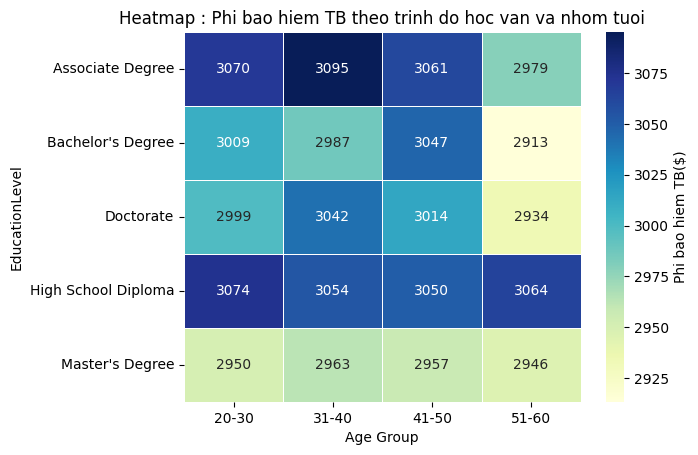

In [4]:
#Cau 4
df_mer=df_customer_data.merge(df_education_level,on='EducationID',how='inner')
df_mer['Age Group']=pd.cut(
    df_mer['Age'],
    bins=[20,30,40,50,60],
    labels=['20-30','31-40','41-50','51-60'],
    right=False
)

pivot=df_mer.pivot_table(index='EducationLevel',columns='Age Group',values='Premium Amount',aggfunc='mean')
sns.heatmap(pivot,annot=True,fmt='.0f',cmap='YlGnBu',linewidths=0.5,cbar_kws={'label':'Phi bao hiem TB($)'})
plt.title('Heatmap : Phi bao hiem TB theo trinh do hoc van va nhom tuoi')

In [5]:
#Cau 5
df_mer05=df_customer_data.merge(df_policy_type,on='PolicyTypeID',how='inner')
df05=df_mer05.groupby(['Age','PolicyType'])['Premium Amount'].mean().reset_index()
fig=px.line(df05,x='Age',y='Premium Amount',color='PolicyType',line_shape='spline',template='plotly_white',title='Xu huong phi bao hiem TB theo do tuoi va loai chinh sach')
fig.update_layout(xaxis_title='Age',
                  yaxis_title='Phi Bao hiem TB',
                  legend_title_text='Loai chinh sach')
fig.show()


In [ ]:
#Cau 6

df_mer06=df_customer_data.merge(df_education_level,on='EducationID',how='inner')
df_06=df_mer06.groupby('EducationLevel',as_index=False)['Premium Amount'].sum().sort_values(by='Premium Amount',ascending=False)  
df_06['Premium Amount']=df_06['Premium Amount']/1_000_000
df_06['Premium Amount_M']=[f'{val:.1f}M 'for val in df_06['Premium Amount']]

print(df_06)
fig=px.bar(df_06,x='EducationLevel',y='Premium Amount',orientation='v',
           text='Premium Amount_M',
           color='EducationLevel',
           title='Tong phi bao hiem theo trinh do hoc van')
fig.update_layout(xaxis_title='Trinh do hoc van',
                  yaxis_title='Tong phi bao hiem',
                  legend_title_text='Trinh do hoc van')
fig.show()


        EducationLevel  Premium Amount Premium Amount_M
0     Associate Degree       37.384804           37.4M 
2            Doctorate       36.458142           36.5M 
3  High School Diploma       32.651876           32.7M 
4      Master's Degree       27.788771           27.8M 
1    Bachelor's Degree       27.493559           27.5M 


: 